# 📘 Домашнє завдання №5. Теорія ймовірності і математична статистика
**Лекція 9-11. Теорія ймовірності і математична статистика**

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW5

In [22]:
import numpy as np


class Reporter:
    """
    Class for collecting and printing data in tabular form
    """

    def __init__(self, attribute_col: str = "Attribute", result_col: str = "Result"):
        self._border_sign = "#"
        self._hor_split_sign = "~"
        self._ver_split_sign = "|"
        self._tolerance = 4
        self._max_len_lf: int = 0
        self._max_len_rt: int = 0
        self._data_list: list[tuple[str, str]] = []
        self.attribute_col = attribute_col
        self.result_col = result_col

    @property
    def max_len_lf(self) -> int:
        """Maximum left column width (the 1st column)"""
        return self._max_len_lf

    @property
    def max_len_rt(self) -> int:
        """Maximum right column width (the 2nd column)"""
        return self._max_len_rt

    @property
    def data_list(self) -> list[tuple[str, str]]:
        """The list of data to be printed"""
        return self._data_list

    @property
    def border_sign(self) -> str:
        """Character used for the outside table border"""
        return self._border_sign

    @border_sign.setter
    def border_sign(self, value: str) -> None:
        self._border_sign = value

    @property
    def hor_split_sign(self) -> str:
        """Character used for horizontal splitter in tabular form"""
        return self._hor_split_sign

    @hor_split_sign.setter
    def hor_split_sign(self, value: str) -> None:
        self._hor_split_sign = value

    @property
    def ver_split_sign(self) -> str:
        """Character used for vertical splitter in tabular form"""
        return self._ver_split_sign

    @ver_split_sign.setter
    def ver_split_sign(self, value: str) -> None:
        self._ver_split_sign = value

    @property
    def tolerance(self) -> int:
        """Number of digits after the floating point"""
        return self._tolerance

    @tolerance.setter
    def tolerance(self, value: int) -> None:
        self._tolerance = value

    @property
    def attribute_col(self) -> str:
        """Name of the attribute (the 1st column)"""
        return self._attribute_col

    @attribute_col.setter
    def attribute_col(self, value: str) -> None:
        array_str_key = value.splitlines()
        for str_key in array_str_key:
            self._max_len_lf = max(self.max_len_lf, len(str_key))
        self._attribute_col = value

    @property
    def result_col(self) -> str:
        """Name of the result (the 2nd column)"""
        return self._result_col

    @result_col.setter
    def result_col(self, value: str) -> None:
        array_str_value = value.splitlines()
        for str_value in array_str_value:
            self._max_len_rt = max(self.max_len_rt, len(str_value))
        self._result_col = value

    def format_value(self, value: float) -> str:
        """
        Format value to string
        :param value: input value
        :return: string of the value
        """
        return f"{value:.{self.tolerance}f}"

    def format_matrix(self, matrix: np.ndarray) -> str:
        """
        Formatting matrix into string
        :param matrix: input matrix
        :return: string of the matrix
        """
        return np.array2string(matrix, precision=self.tolerance)

    def add_item(self, key: str, value: str) -> None:
        """
        Form the report data that consist multi strings
        :param key: attribute
        :param value: result
        """
        array_str_key = key.splitlines()
        array_str_value = value.splitlines()

        for str_key in array_str_key:
            self._max_len_lf = max(self.max_len_lf, len(str_key))

        for str_value in array_str_value:
            self._max_len_rt = max(self.max_len_rt, len(str_value))

        self._data_list.append((key, value))

    def _print_line_splitter(self, sign: str = "-") -> None:
        """
        Print line splitter
        """
        print(sign * (self.max_len_lf + self.max_len_rt + 5))

    def _print_multi_string(self, row: tuple[str, str]) -> None:
        """
        Print the multi string
        :param row: tuple of data
        """
        array_str_key = row[0].splitlines()
        array_str_value = row[1].splitlines()
        num_str = max(len(array_str_key), len(array_str_value))

        for index in range(num_str):
            if index < len(array_str_key):
                left_str = f"{f"{array_str_key[index]}":<{self.max_len_lf}}"
            else:
                left_str = f"{f" ":<{self.max_len_lf}}"

            if index < len(array_str_value):
                right_str = f"{f"{array_str_value[index]:<{self.max_len_rt}}"}"
            else:
                right_str = f"{f" ":<{self.max_len_rt}}"

            print(f" {left_str} {self.ver_split_sign} {right_str}")

    def refresh_table_config(self) -> None:
        """
        Refresh table configuration, like line lengths
        :return:
        """
        self._max_len_lf = 0
        self._max_len_rt = 0

        self.attribute_col = self.attribute_col
        self.result_col = self.result_col

        temp_data_list = self.data_list
        self._data_list = []
        for temp_data in temp_data_list:
            self.add_item(temp_data[0], temp_data[1])

    def print_report(self) -> None:
        """
        Print report data
        """
        self._print_line_splitter(self.border_sign)
        self._print_multi_string((self.attribute_col, self.result_col))
        self._print_line_splitter(self.border_sign)
        for item_data in self.data_list[0:-1]:
            self._print_multi_string(item_data)
            self._print_line_splitter("~")
        self._print_multi_string(self.data_list[-1])
        self._print_line_splitter(self.border_sign)

    def print_refreshed_report(self) -> None:
        """
        Print report data with a refreshing table
        """
        self.refresh_table_config()
        self.print_report()


## Задача 1. Формула Бернуллі

**Умова**:

У A/B тесті конверсія нової кнопки становить 20%. 10 користувачів натискають кнопку.

* Обчисліть ймовірність, що рівно 3 користувачі натиснуть кнопку, використовуючи формулу Бернуллі.
* Обчисліть ймовірність, що не менше 2 користувачів натиснуть кнопку.

**Підказка**:

`math.comb(n, k)` для комбінацій

**Формула**:
$$P(X=k)=C_n^k p^k(1−p)^{n-k}$$


In [82]:
#### Variant №1 ####

import math

# Input data
n = 10  # кількість користувачів
p = 0.2  # ймовірність успіху (конверсія)
# 1. Рівно 3 успіхи
k_1 = 3
# 2. Не менше 2 успіхів
k_2 = 2

# Solution
bern_f = lambda k, n, p: math.comb(n, k) * math.pow(p, k) * math.pow(1 - p, n - k)

# 1. Рівно 3 успіхи
prob_exact_3 = bern_f(k_1, n, p)

# 2. Не менше 2 успіхів
# прямий розрахунок
prob_at_least_2_v1 = 0.0

for item in range(2, n + 1):
    prob_at_least_2_v1 += bern_f(item, n, p)

# зворотний розрахунок
opposite_prob_at_least_2 = 0.0
for item in range(0, k_2):
    opposite_prob_at_least_2 += bern_f(item, n, p)

prob_at_least_2_v2 = 1 - opposite_prob_at_least_2

# Print results
rp = Reporter()
rp.tolerance = 6
rp.add_item("Кількість користувачів", str(n))
rp.add_item("Ймовірність успіху\n(конверсія)", f"{p:.2%}")
rp.add_item("Ймовірність рівно 3 успіхів", rp.format_value(prob_exact_3))
rp.add_item("Ймовірність не менше 2 успіхів\n(прямий розрахунок)", rp.format_value(prob_at_least_2_v1))
rp.add_item("Ймовірність не менше 2 успіхів\n(зворотний розрахунок)", rp.format_value(prob_at_least_2_v2))
rp.print_refreshed_report()

###########################################
 Attribute                      | Result  
###########################################
 Кількість користувачів         | 10      
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Ймовірність успіху             | 20.00%  
 (конверсія)                    |         
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Ймовірність рівно 3 успіхів    | 0.201327
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Ймовірність не менше 2 успіхів | 0.624190
 (прямий розрахунок)            |         
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Ймовірність не менше 2 успіхів | 0.624190
 (зворотний розрахунок)         |         
###########################################


## Задача 2. Розподіл Бернуллі

**Умова**:
Уявіть, що користувач натискає на кнопку з ймовірністю $p=0.3$.

* Згенеруйте 1000 незалежних спроб (`Bernoulli`).
* Обчисліть середнє та дисперсію емпірично.



Source: [Wiki](https://uk.wikipedia.org/wiki/Розподіл_Бернуллі)

In [81]:
#### Variant №1 ####

import numpy as np
import pandas as pd

# Input data
p = 0.3
n_trials = 1000

# Solution
np.random.seed(42)
bern_samples = np.random.binomial(n=1, p=p, size=n_trials)

mean_teor = p
mean_bern = np.mean(bern_samples)

var_teor = p * (1 - p)
var_bern = np.var(bern_samples, ddof=1)
var_bern_gen = np.var(bern_samples)

std_teor = math.sqrt(var_teor)
std_bern = math.sqrt(var_bern)
std_bern_gen = math.sqrt(var_bern_gen)

# cv_teor -> var_teor / mean_teor = p * (1 - p) / p = 1 - p
cv_teor = 1 - p
cv_bern = var_bern / mean_bern
cv_bern_gen = var_bern_gen / mean_bern

# Print results
df = pd.DataFrame({"Натискання кнопки": bern_samples})
display(df)
rp = Reporter()
rp.tolerance = 6
rp.add_item("Кількість\nнатискань кнопки", str(n_trials))
rp.add_item("Ймовірність\nнатискання кнопки", f"{p:.2%}")
rp.add_item("Середнє\n(Theoretical)", rp.format_value(mean_teor))
rp.add_item("Середнє\n(Bernoulli, Empirical)", rp.format_value(float(mean_bern)))
rp.add_item("Дисперсія\n(Theoretical)", rp.format_value(var_teor))
rp.add_item("Дисперсія вибірки\n(Bernoulli, Empirical)", rp.format_value(float(var_bern)))
rp.add_item("Дисперсія генеральної сукупності\n(Bernoulli, Empirical)", rp.format_value(float(var_bern_gen)))
rp.add_item("СКО\n(Theoretical)", rp.format_value(std_teor))
rp.add_item("СКО вибірки\n(Bernoulli, Empirical)", rp.format_value(float(std_bern)))
rp.add_item("СКО генеральної сукупності\n(Bernoulli, Empirical)", rp.format_value(float(std_bern_gen)))
rp.add_item("Коефіцієнт варіації\n(Theoretical)", rp.format_value(cv_teor))
rp.add_item("Коефіцієнт варіації вибірки\n(Bernoulli, Empirical)", rp.format_value(float(cv_bern)))
rp.add_item("Коефіцієнт варіації генеральної сукупності\n(Bernoulli, Empirical)", rp.format_value(float(cv_bern_gen)))
rp.print_refreshed_report()

,Натискання кнопки
0,0
1,1
2,1
3,0
4,0
...,...
995,0
996,1
997,0
998,1


#######################################################
 Attribute                                  | Result  
#######################################################
 Кількість                                  | 1000    
 натискань кнопки                           |         
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Ймовірність                                | 30.00%  
 натискання кнопки                          |         
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Середнє                                    | 0.300000
 (Theoretical)                              |         
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Середнє                                    | 0.288000
 (Bernoulli, Empirical)                     |         
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Дисперсія                                  | 0.210000
 (Theoretical)                              |         
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Ди

## Задача 3. Нормальний розподіл і стандартизація

**Умова**:
1. Згенеруйте 10000 випадкових чисел з Normal($\mu=50$, $\sigma=10$).
2. Обчисліть середнє та дисперсію емпірично.
3. Стандартизуйте дані (`Z-score`) і перевірте, що нове середнє $\approx$ 0, дисперсія $\approx$ 1.

**Підказка**:
$$Z = \frac{X-mean}{std}$$

In [124]:
#### Variant №1 ####

import numpy as np

# Input data
mu, sigma, sample_size = 50, 10, 10000

# Solution
np.random.seed(42)
normal_data = np.random.normal(mu, sigma, size=sample_size)

mean_normal = np.mean(normal_data)

var_normal = np.var(normal_data, ddof=1)
var_normal_gen = np.var(normal_data)

std_normal = np.std(normal_data, ddof=1)
std_normal_gen = np.std(normal_data)

# Стандартизація (Z-score)
z_scores = (normal_data - mean_normal) / std_normal
z_scores_gen = (normal_data - mean_normal) / std_normal_gen

mean_z_scores = np.mean(z_scores)
mean_z_scores_gen = np.mean(z_scores_gen)

var_z_scores = np.var(z_scores, ddof=1)
var_z_scores_gen = np.var(z_scores_gen)

std_z_scores = np.std(z_scores, ddof=1)
std_z_scores_gen = np.std(z_scores_gen)

# Print results
df = pd.DataFrame({"Вибірка": normal_data, "Стандартизована вибірка": z_scores,
                   "Стандартизована генеральна сукупність": z_scores_gen})
display(df)
rp = Reporter()
rp.tolerance = 6
rp.add_item("Кількість значень", str(sample_size))
rp.add_item("Математичне сподівання", str(mu))
rp.add_item("Дисперсія", str(sigma))
rp.add_item("Середнє арифметичне\n(Original)", rp.format_value(float(mean_normal)))
rp.add_item("Дисперсія вибірки\n(поправка Бесселя)", rp.format_value(float(var_normal)))
rp.add_item("Дисперсія генеральної сукупності", rp.format_value(float(var_normal_gen)))
rp.add_item("СКО вибірки", rp.format_value(float(std_normal)))
rp.add_item("СКО генеральної сукупності", rp.format_value(float(std_normal_gen)))

rp.add_item("Середнє арифметичне вибірки\n(Standardized, Z-score)", rp.format_value(float(mean_z_scores)))
rp.add_item("Середнє арифметичне генеральної сукупності\n(Standardized, Z-score)",
            rp.format_value(float(mean_z_scores_gen)))
rp.add_item("Дисперсія вибірки\n(Z-score)", rp.format_value(float(var_z_scores)))
rp.add_item("Дисперсія генеральної сукупності\n(Z-score)", rp.format_value(float(var_z_scores_gen)))
rp.add_item("СКО вибірки\n(Z-score)", rp.format_value(float(std_z_scores)))
rp.add_item("СКО генеральної сукупності\n(Z-score)", rp.format_value(float(std_z_scores_gen)))
rp.print_refreshed_report()

,Вибірка,Стандартизована вибірка,Стандартизована генеральна сукупність
0,54.967142,0.497129,0.497154
1,48.617357,-0.135659,-0.135665
2,56.476885,0.647582,0.647615
3,65.230299,1.519903,1.519979
4,47.658466,-0.231217,-0.231228
...,...,...,...
9995,63.011021,1.298741,1.298806
9996,30.016550,-1.989321,-1.989421
9997,42.946833,-0.700754,-0.700790
9998,54.957656,0.496184,0.496208


#########################################################
 Attribute                                  | Result    
#########################################################
 Кількість значень                          | 10000     
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Математичне сподівання                     | 50        
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Дисперсія                                  | 10        
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Середнє арифметичне                        | 49.978640 
 (Original)                                 |           
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Дисперсія вибірки                          | 100.693675
 (поправка Бесселя)                         |           
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Дисперсія генеральної сукупності           | 100.683606
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 СКО вибірки           

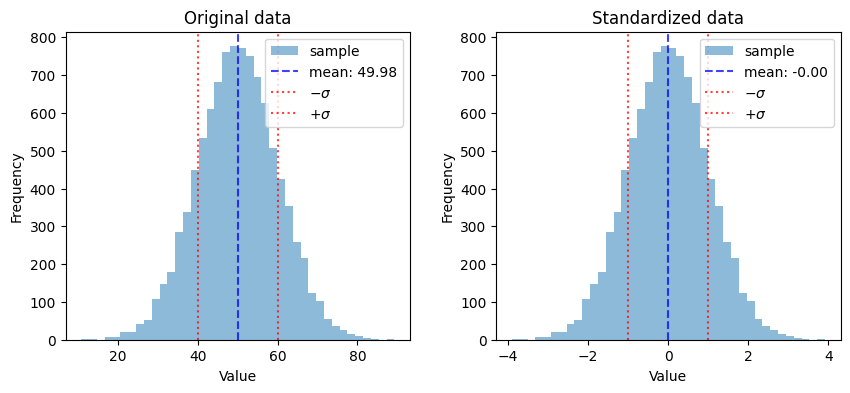

In [170]:
import matplotlib.pyplot as plt

# Graphic results
plt.figure(figsize=(10, 4))
plt.subplots_adjust(wspace=0.25)

ax = plt.subplot(1, 2, 1)
plt.hist(normal_data, bins=40, alpha=0.5, label="sample")
plt.axvline(float(mean_normal), linestyle='--', color='blue', alpha=0.75, label=f"mean: {mean_normal:.2f}")
plt.axvline(float(mean_normal - std_normal), linestyle=':', color='red', alpha=0.75, label=fr"$-\sigma$")
plt.axvline(float(mean_normal + std_normal), linestyle=':', color='red', alpha=0.75, label=fr"$+\sigma$")
plt.legend()
plt.title("Original data")
plt.ylabel("Frequency")
plt.xlabel("Value")

ax = plt.subplot(1, 2, 2)
plt.hist(z_scores, bins=40, alpha=0.5, label="sample")
plt.axvline(float(mean_z_scores), linestyle='--', color='blue', alpha=0.75, label=f"mean: {mean_z_scores:.2f}")
plt.axvline(float(mean_z_scores - std_z_scores), linestyle=':', color='red', alpha=0.75, label=fr"$-\sigma$")
plt.axvline(float(mean_z_scores + std_z_scores), linestyle=':', color='red', alpha=0.75, label=fr"$+\sigma$")
plt.legend()
plt.title("Standardized data")
plt.ylabel("Frequency")
plt.xlabel("Value")

plt.show()

## Задача 4. Кореляція та коваріація

Згенеруйте дві змінні X і Y так, щоб Y = 3X + шум (нормальний).

* Обчисліть коваріацію та кореляцію Пірсона.
* Додайте кілька аутлаєрів і порівняйте, як змінилась кореляція.
* Обчисліть кореляцію Спірмена

In [208]:
#### Variant №1 ####

import numpy as np
from scipy import stats

# Input data
x_min = -3
x_max = 3
noise_min = -3
noise_max = 3
n_size = 250
multi_outliers = 2
n_outliers = 5

# Solution
np.random.seed(42)

# 1. Генеруємо змінні
x = np.linspace(x_min, x_max, n_size)
y = 3 * x + np.random.normal(noise_min, noise_max, n_size)

# індекси для аутлаєрів
idx_outliers = np.random.randint(n_size, size=n_outliers)

# модифікуємо дані
x_emission_size = multi_outliers * max(abs(x_min), abs(x_max))
y_min = y.min()
y_max = y.max()
y_emission_size = multi_outliers * max(abs(y_min), abs(y_max))

print("emission_size:", y_emission_size)
print("emission_size:", x_emission_size)

k = x.copy()
z = y.copy()
for idx in idx_outliers:
    k[idx] += np.random.choice([-1, 1]) * x_emission_size
    z[idx] += np.random.choice([-1, 1]) * y_emission_size

print("idx_outliers", idx_outliers)

# # 2. Коваріація
# cov_xy =  #
#
# # 3. Кореляція Пірсона
# pearson_r, pearson_p =  #
#
# # 4. Кореляція Спірмена
# spearman_rho, spearman_p =  #

# Print results
df = pd.DataFrame({"X": x, "Y": y, "K": k, "Z": z})
display(df)
# print("Covariance:", cov_xy)
# print("Pearson r:", pearson_r, "p-value:", pearson_p)
# print("Spearman rho:", spearman_rho, "p-value:", spearman_p)

emission_size: 33.60016339565763
emission_size: 6
idx_outliers [231 236 116 128  15]


,X,Y,K,Z
0,-3.000000,-10.509858,-3.000000,-10.509858
1,-2.975904,-12.342504,-2.975904,-12.342504
2,-2.951807,-9.912356,-2.951807,-9.912356
3,-2.927711,-7.214043,-2.927711,-7.214043
4,-2.903614,-12.413303,-2.903614,-12.413303
...,...,...,...,...
245,2.903614,4.707340,2.903614,4.707340
246,2.927711,4.358297,2.927711,4.358297
247,2.951807,3.895434,2.951807,3.895434
248,2.975904,11.224074,2.975904,11.224074


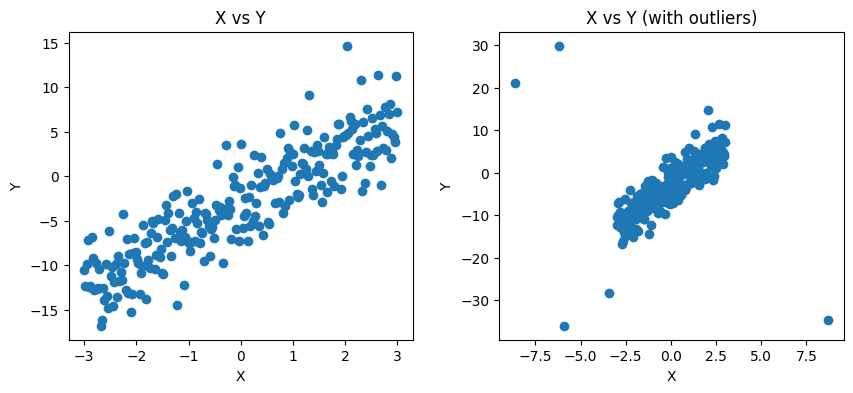

In [206]:
import matplotlib.pyplot as plt

# Graphic results
plt.figure(figsize=(10, 4))
plt.subplots_adjust(wspace=0.25)

ax = plt.subplot(1, 2, 1)
plt.scatter(x, y)
plt.title("X vs Y")
plt.ylabel("Y")
plt.xlabel("X")

ax = plt.subplot(1, 2, 2)
plt.scatter(k, z)
plt.title("X vs Y (with outliers)")
plt.ylabel("Y")
plt.xlabel("X")

plt.show()

## Задача 5. Точкові оцінки та довірчі інтервали

Згенеруйте вибірку `n=50` з нормального розподілу.

Обчисліть точкові оцінки: `mean`, `median`, `std`.

Побудуйте 95% довірчий інтервал для середнього через `t`-розподіл.

Побудуйте 95% CI через bootstrap (2000 вибірок).

In [ ]:
np.random.seed(42)

# 1. Генеруємо вибірку
data =  #np.random.normal ...
n =  #
mean =  #
median =  #
std =  # np.std, ddof=1

print("Mean:", mean)
print("Median:", median)
print("Std:", std)

# 2. 95% CI через t-розподіл
alpha = 0.05
t_crit =  #
se =  #
ci_lower =  #
ci_upper =  #

print("\n95% CI (t-based):", (ci_lower, ci_upper))

# 3. Bootstrap 95% CI
B = 2000
boot_means = []

# Ваш код тут

print("95% CI (bootstrap):", (ci_boot_lower, ci_boot_upper))

## Задача 6: Категоріальні дані та $\chi^2$ тест

Згенеруйте дані про 200 користувачів:
* `button_type ∈ {A, B}`
* `user_segment ∈ {New, Returning}`

Побудуйте таблицю частот (crosstab), проведіть $\chi^2$ тест незалежності. Інтерпретуйте $p$-value та expected frequencies.

Сформулюйте висновок для бізнес-кейсу (чи залежить click rate від сегменту).

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# 1. Генеруємо дані
n = 200

button_type_arr =  #використайте функцію np.random.choice для можливих значень кнопки
user_segment_arr =  #використайте функцію np.random.choice для можливих значень сегменту

data = pd.DataFrame({
    'button_type': button_type_arr,
    'user_segment': user_segment_arr
})

# 2. Таблиця частот
freq_table =  #використайте функцію pd.crosstab
print("Frequency table:\n", freq_table)

# 3. χ² тест незалежності
chi2_stat, p_val, dof, expected =  # використайте stats.chi2_contingency
print("\nChi-square test:")
print("Chi2 statistic:", chi2_stat)
print("p-value:", p_val)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected)

if p_val < 0.05:
#
else:
#

## Задача 7. Перевірка гіпотез (t-test і CI)

Згенеруйте дві групи A і B (`n_A=60`, `n_B=65`) з нормальних розподілів, середні 100 і 107, `std=15`.

Проведіть t-test для незалежних вибірок.

Обчисліть 95% CI для різниці середніх.

Інтерпретуйте p-value та CI: чи є статистично значуща різниця?

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)

# 1. Генеруємо дві групи
n_A = 60
n_B = 65
group_A =  # np.random.normal
group_B =  #

mean_A =  #
mean_B =  #

print("Mean A:", mean_A)
print("Mean B:", mean_B)

# 2. Welch's t-test (незалежні вибірки, unequal var)
t_stat, p_value =  #
print("\nT-statistic:", t_stat)
print("p-value:", p_value)

# 3. 95% CI для різниці середніх
diff = mean_B - mean_A
std_A =  #
std_B =  #
se =  #

# ступені свободи для Welch
df =  #

alpha = 0.05
t_crit =  #
ci_lower = diff - t_crit * se
ci_upper = diff + t_crit * se
print("Difference (B - A):", diff)
print("95% CI:", (ci_lower, ci_upper))